In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sys.path.append(os.path.abspath('../'))
from scripts.forecast_models import split_time_series_data, generate_future_forecast

# 1. Load data and models
prices = pd.read_csv('../data/processed/cleaned_prices.csv', index_col=0, parse_dates=True)
train, test = split_time_series_data(prices, target_col='TSLA', split_date='2025-01-01')

with open('../models/arima_model.pkl', 'rb') as f:
    fitted_arima = pickle.load(f)

# 2. Generate a 252-day (12-month) out-of-sample forecast
future_mean, future_ci = generate_future_forecast(fitted_arima, test, steps=252)

# Save future projections for our downstream portfolio optimizer (Task 4)
os.makedirs('../data/processed/', exist_ok=True)
future_mean.to_csv('../data/processed/tsla_future_forecast.csv')
print("Future forecasts successfully generated and cached!")

Generating out-of-sample future forecast for 252 trading days...
Future forecasts successfully generated and cached!


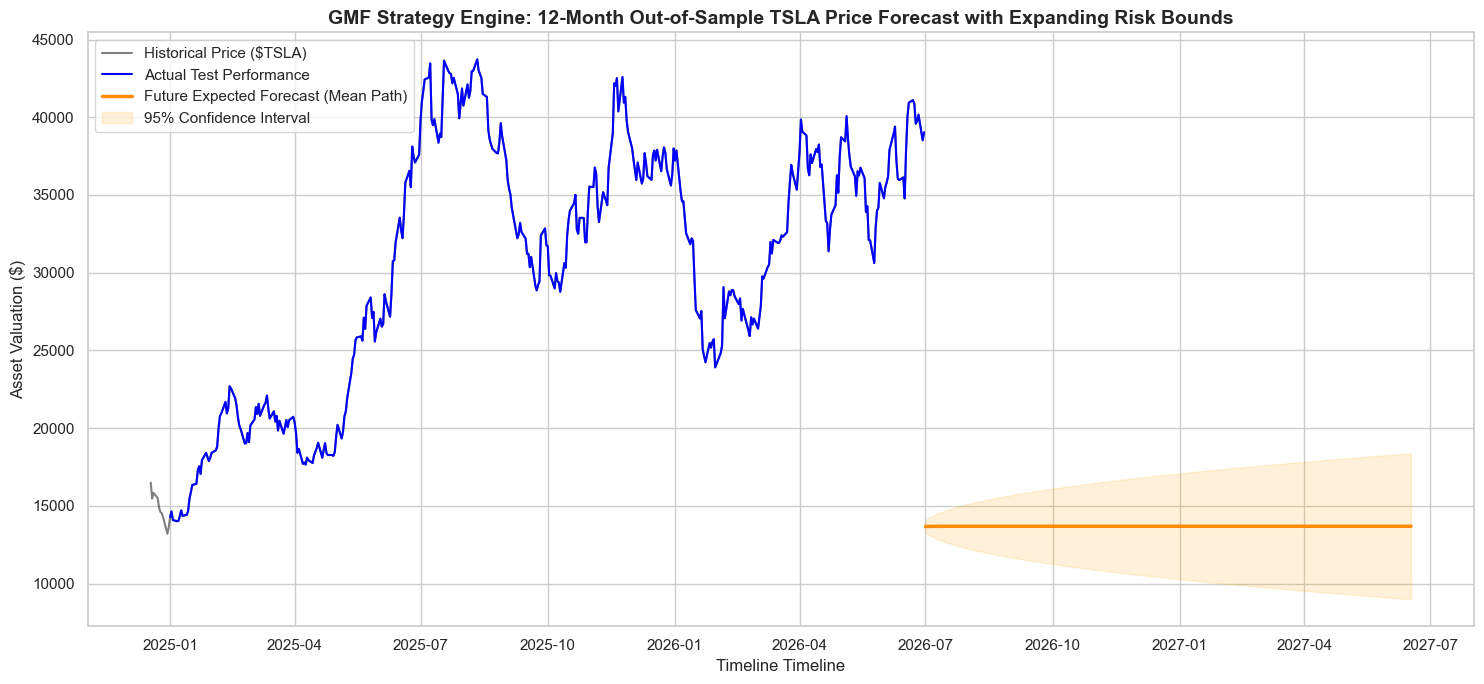

In [2]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# Plot historical backdrop (Recent 1.5 years for clarity)
plt.plot(prices.index[-400:], prices['TSLA'].tail(400), label="Historical Price ($TSLA)", color="black", alpha=0.5)

# Plot test period tracking
plt.plot(test.index, test.values, label="Actual Test Performance", color="blue", linewidth=1.5)

# Plot the out-of-sample future forecast mean line
plt.plot(future_mean.index, future_mean.values, label="Future Expected Forecast (Mean Path)", color="darkorange", linewidth=2.5)

# Fill expanding uncertainty bounds (Confidence Intervals)
plt.fill_between(future_ci.index, 
                 future_ci.iloc[:, 0], 
                 future_ci.iloc[:, 1], 
                 color='orange', alpha=0.15, label='95% Confidence Interval')

plt.title("GMF Strategy Engine: 12-Month Out-of-Sample TSLA Price Forecast with Expanding Risk Bounds", fontsize=14, fontweight='bold')
plt.ylabel("Asset Valuation ($)")
plt.xlabel("Timeline Timeline")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()